# Initial Data Loading & Inspection


In [3]:
import os
import pandas as pd
import numpy as np

# Load the dataset
data_path = os.path.join('data', 'insurance.csv')
df = pd.read_csv(data_path)

# Dataset structure
print("--- Dataset Shape ---")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}\n")

print("--- Data Info ---")
print(df.info())
print("\n--- Missing Values ---")
print(df.isnull().sum())

# Preview of the first few rows
print("\n--- First 5 Rows ---")
print(df.head())

--- Dataset Shape ---
Rows: 1338, Columns: 7

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None

--- Missing Values ---
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

--- First 5 Rows ---
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.4620

In [4]:
# Summary statistics

print("--- Numerical Feature Statistics ---")
print(df.describe())

print("\n--- Categorical Feature Value Counts ---")
for col in df.select_dtypes(include=['object']).columns:
    print(f"\nValue counts for '{col}':")
    print(df[col].value_counts())

--- Numerical Feature Statistics ---
               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010

--- Categorical Feature Value Counts ---

Value counts for 'sex':
sex
male      676
female    662
Name: count, dtype: int64

Value counts for 'smoker':
smoker
no     1064
yes     274
Name: count, dtype: int64

Value counts for 'region':
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


# Visualization
1. Distribution of Medical Insurance Charges
2. Categorical Features vs. Charges
3. BMI vs. Charges, color-coded points for *smoker* status

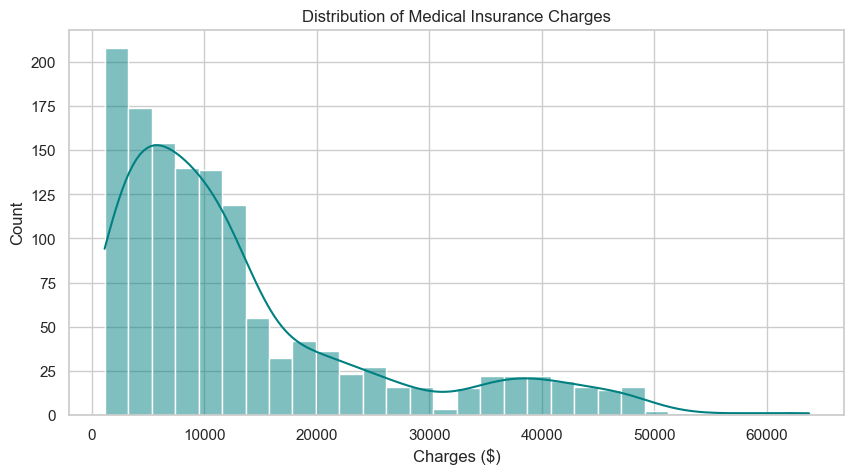

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 5))
sns.histplot(df['charges'], kde=True, color='teal')
plt.title('Distribution of Medical Insurance Charges')
plt.xlabel('Charges ($)')
plt.ylabel('Count')
plt.show()

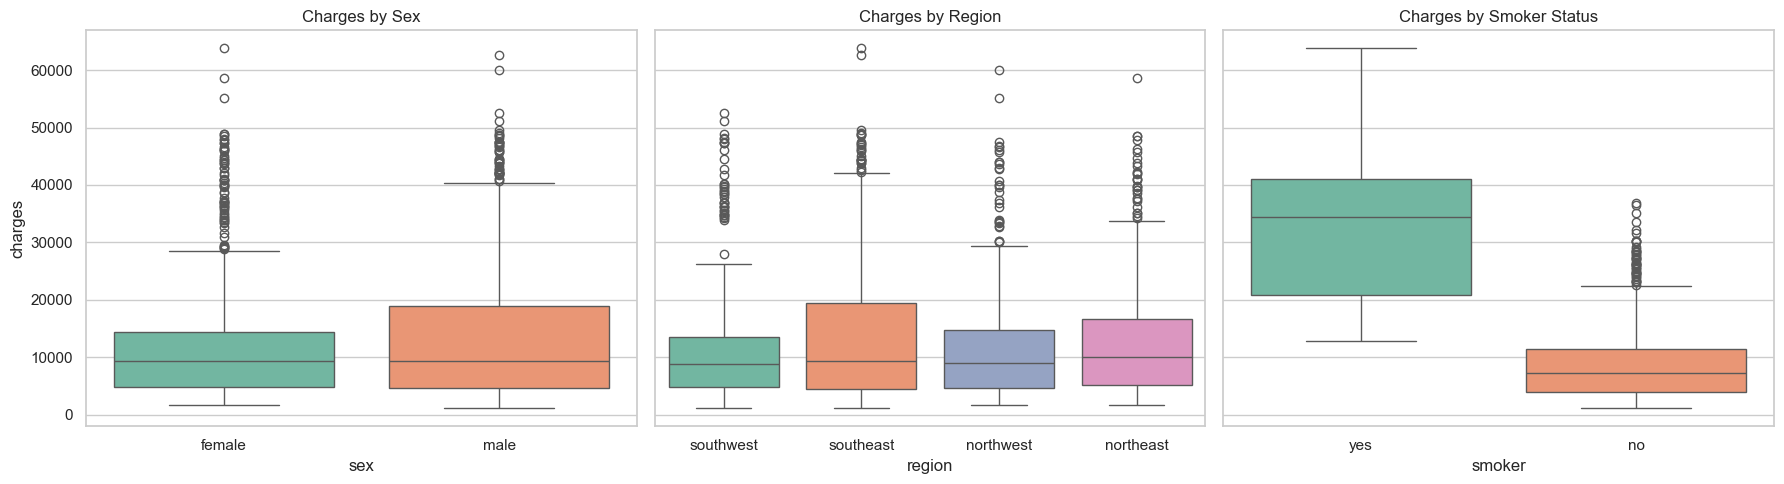

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# Sex vs Insurance Charges 
sns.boxplot(ax=axes[0], x='sex', y='charges', data=df, hue='sex', palette='Set2', legend=False)
axes[0].set_title('Charges by Sex')

# Region vs Insurance Charges 
sns.boxplot(ax=axes[1], x='region', y='charges', data=df, hue='region', palette='Set2', legend=False)
axes[1].set_title('Charges by Region')

# Smoker vs Insurance Charges 
sns.boxplot(ax=axes[2], x='smoker', y='charges', data=df, hue='smoker', palette='Set2', legend=False)
axes[2].set_title('Charges by Smoker Status')

plt.tight_layout()
plt.show()

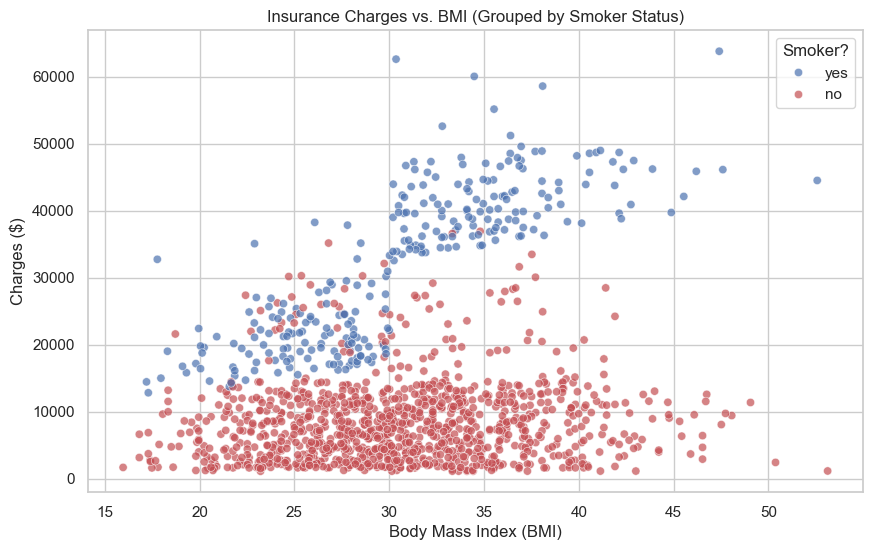

In [7]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='bmi', y='charges', hue='smoker', data=df, alpha=0.7, palette=['#4c72b0', '#c44e52'])
plt.title('Insurance Charges vs. BMI (Grouped by Smoker Status)')
plt.xlabel('Body Mass Index (BMI)')
plt.ylabel('Charges ($)')
plt.legend(title='Smoker?')
plt.show()

# Building the Baseline Model

In [8]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Converting categorical columns (sex, smoker, and region) into numbers
df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)

# Defining x (features matrix) and y (target vector)
X = df_encoded.drop(columns=['charges'])
y = df_encoded['charges']

# 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} rows")
print(f"Testing set size: {X_test.shape[0]} rows")

Training set size: 1070 rows
Testing set size: 268 rows


In [9]:
# initialize and fit the model to our training data
baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)

# generate predictions on the test set
y_pred_baseline = baseline_model.predict(X_test)

# calculate evaluation metrics using R^2 (variance the model explains) and RMSE (average error size in dollars)
r2_baseline = r2_score(y_test, y_pred_baseline)
rmse_baseline = np.sqrt(mean_squared_error(y_test, y_pred_baseline))

print("--- Baseline Model Performance ---")
print(f"R-squared (R²): {r2_baseline:.4f}")  # The model explains about 78.3% of variance in insurance costs
print(f"RMSE: ${rmse_baseline:,.2f}")        # On average, the model's predictions are off by around $5,800

--- Baseline Model Performance ---
R-squared (R²): 0.7836
RMSE: $5,796.28


# Building The Interaction Model & Comparing To The Baseline Model


In [10]:

# Create explicit copies to avoid SettingWithCopyWarning
X_train_int = X_train.copy()
X_test_int = X_test.copy()

# Create the interaction term: BMI multiplied by the Smoker flag
X_train_int['bmi_x_smoker'] = X_train_int['bmi'] * X_train_int['smoker_yes']
X_test_int['bmi_x_smoker'] = X_test_int['bmi'] * X_test_int['smoker_yes']

# Initialize and fit the updated model
interaction_model = LinearRegression()
interaction_model.fit(X_train_int, y_train)

# Predict on the testing set using the interaction features
y_pred_interaction = interaction_model.predict(X_test_int)

In [11]:
# Calculate interaction model metrics
r2_interaction = r2_score(y_test, y_pred_interaction)
rmse_interaction = np.sqrt(mean_squared_error(y_test, y_pred_interaction))

print("=============================================")
print("          MODEL PERFORMANCE COMPARISON       ")
print("=============================================")
print(f"Baseline Model:")
print(f"  -> R-squared: {r2_baseline:.4f}")
print(f"  -> RMSE:      ${rmse_baseline:,.2f}")
print("---------------------------------------------")
print(f"Interaction Model:")
print(f"  -> R-squared: {r2_interaction:.4f}")
print(f"  -> RMSE:      ${rmse_interaction:,.2f}")
print("=============================================")

# Calculate absolute improvement
rmse_diff = rmse_baseline - rmse_interaction
print(f"\nSuccess! Your average prediction error dropped by ${rmse_diff:,.2f} per person.")

          MODEL PERFORMANCE COMPARISON       
Baseline Model:
  -> R-squared: 0.7836
  -> RMSE:      $5,796.28
---------------------------------------------
Interaction Model:
  -> R-squared: 0.8653
  -> RMSE:      $4,573.81

Success! Your average prediction error dropped by $1,222.48 per person.


R-squared jumps from 0.7836 to 0.8653;

RMSE drops from $5796.28 to $4,573.81

The model has improved by accounting for the status on whether the person is a smoker or not. Miscalculations have been lowered as seen with the drop in RMSE, and an 8% addition in R-squared shows that the model now has an even tighter fit of the data to the regression line. 

# Residuals 
In addition to looking at R-squared, we will also look at the errors (residuals). If our model successfully captured all of the structured signals in the data, the remaining errors should look completely random. If the errors have a pattern, it shows that our model is missing something critical

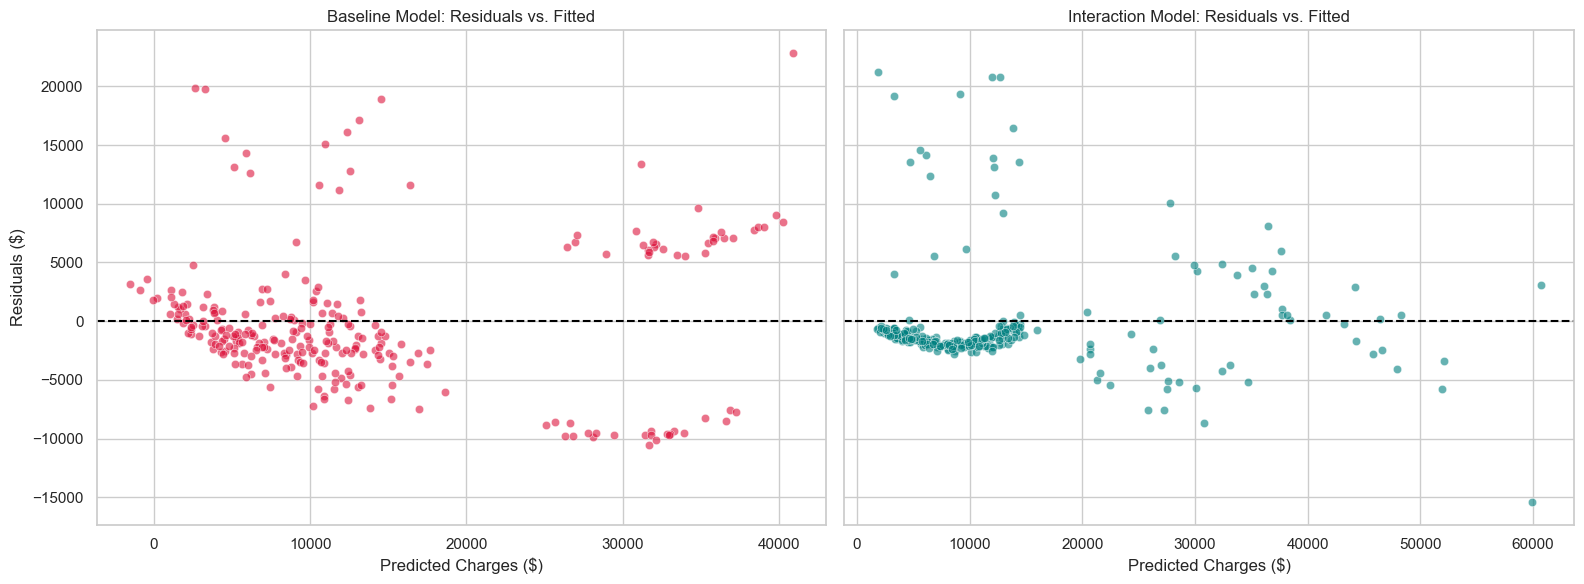

In [12]:
# Calculate the residuals for both models
residuals_baseline = y_test - y_pred_baseline
residuals_interaction = y_test - y_pred_interaction

# Group the residuals into a temporary dataframe
res_df = pd.DataFrame({
    'Actual': y_test,
    'Pred_Baseline': y_pred_baseline,
    'Res_Baseline': residuals_baseline,
    'Pred_Interaction': y_pred_interaction,
    'Res_Interaction': residuals_interaction
})

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# 1. Baseline Residual Plot
sns.scatterplot(ax=axes[0], x='Pred_Baseline', y='Res_Baseline', data=res_df, alpha=0.6, color='crimson')
axes[0].axhline(y=0, color='black', linestyle='--')
axes[0].set_title('Baseline Model: Residuals vs. Fitted')
axes[0].set_xlabel('Predicted Charges ($)')
axes[0].set_ylabel('Residuals ($)')

# 2. Interaction Model Residual Plot
sns.scatterplot(ax=axes[1], x='Pred_Interaction', y='Res_Interaction', data=res_df, alpha=0.6, color='teal')
axes[1].axhline(y=0, color='black', linestyle='--')
axes[1].set_title('Interaction Model: Residuals vs. Fitted')
axes[1].set_xlabel('Predicted Charges ($)')

plt.tight_layout()
plt.show()

- The Baseline model is under-predicting the cost in charges for certain individuals
- The Interaction model is much closer together in, which looks like a distinct bend, showing that the added *smoker status* fixed a big bulk of error seen in the baseline model.

# Normality

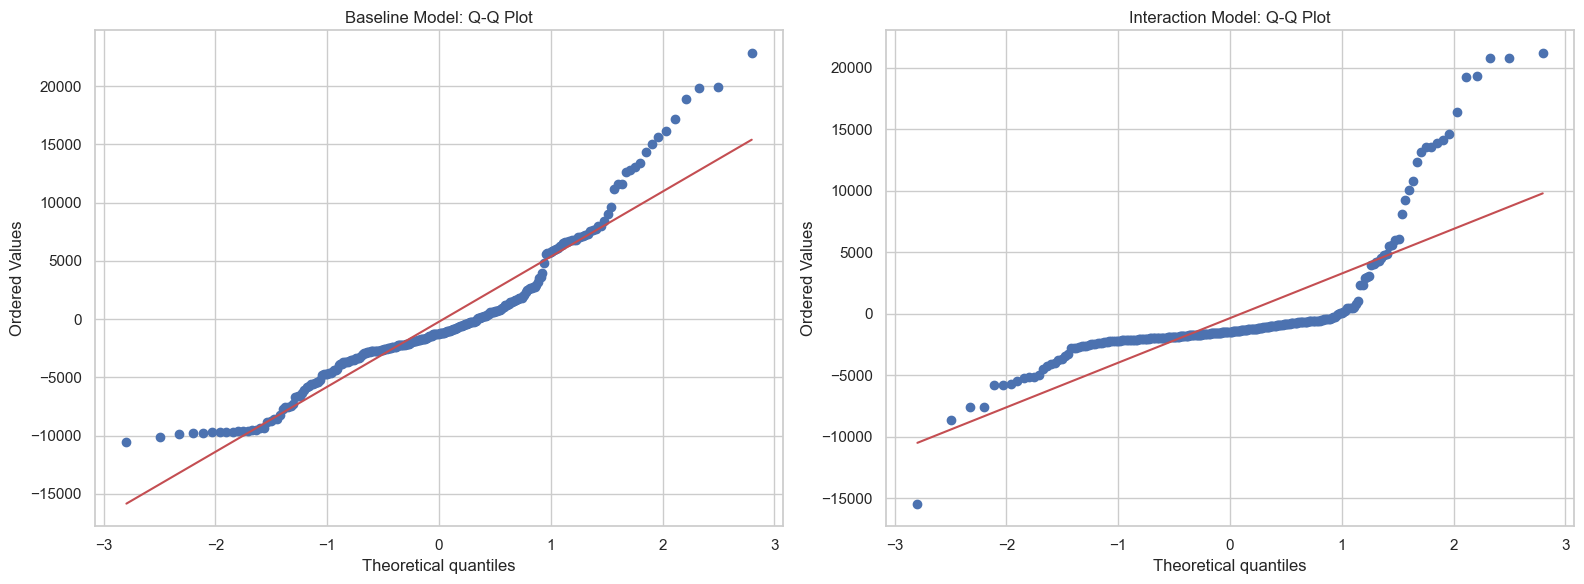

In [13]:
from scipy import stats

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Q-Q plot for Baseline
stats.probplot(residuals_baseline, dist="norm", plot=axes[0])
axes[0].set_title('Baseline Model: Q-Q Plot')

# Q-Q plot for Interaction
stats.probplot(residuals_interaction, dist="norm", plot=axes[1])
axes[1].set_title('Interaction Model: Q-Q Plot')

plt.tight_layout()
plt.show()

In both Q-Q plots, the lines have an S shape, showing that the model is still under or over predicting values, causing extreme outliers. 

# Model Interpretation

In [14]:
# Create a DataFrame to store feature names and their corresponding weights
coefficients_df = pd.DataFrame({
    'Feature': X_train_int.columns,
    'Coefficient (Weight)': interaction_model.coef_
})

# Add the intercept row at the top
intercept_row = pd.DataFrame({'Feature': ['Intercept (Baseline Cost)'], 'Coefficient (Weight)': [interaction_model.intercept_]})
coefficients_df = pd.concat([intercept_row, coefficients_df], ignore_index=True)

# Format the output for easy reading
coefficients_df['Coefficient (Weight)'] = coefficients_df['Coefficient (Weight)'].map('${:,.2f}'.format)
print(coefficients_df)

                     Feature Coefficient (Weight)
0  Intercept (Baseline Cost)           $-2,041.66
1                        age              $263.39
2                        bmi               $20.25
3                   children              $463.65
4                   sex_male             $-525.23
5                 smoker_yes          $-21,206.91
6           region_northwest             $-631.42
7           region_southeast             $-967.48
8           region_southwest           $-1,233.43
9               bmi_x_smoker            $1,470.86


- Intercept: $-2,041.66
    - This is the baseline for individuals when all numerical features are 0 and all categorical variables are at a default state.
- Linear Effects:
    - Age: For every year an individual's age increases, their medical insurance premium increases by roughly $263.39, assuming that their other lifestyle factors are consistant
    - Children: Each dependent child adds a fixed cost of around $463.65 to the annual premium
- Risks (Main Insight):
    - BMI: This represents the impact of BMI for non-smokers, which is around $20.25 per BMI point.
    - smoker_yes: This is the base penalty for smoking. However, because we included this as an interaction term, this specific number represents the smoking penalty if the person's BMI were theoretically zero.
    - bmi_smoker: This represents the BMI for smokers, showing a significant amount of 1,470.86 for every BMI the smoker gains on top of the baseline rate.  

In [15]:
import joblib

# Save the trained interaction model to a file
joblib.dump(interaction_model, 'interaction_model.pkl')
print("Model successfully saved as 'interaction_model.pkl'!")

Model successfully saved as 'interaction_model.pkl'!
